In [1]:
## load dataset 
import pandas as pd

df = pd.read_csv("social_media_productivity_6000.csv")

In [2]:
## EDA
print(f"Cek 5 data teratas \n {df.head()} \n")

print(f"Cek Tipe data \n {df.dtypes} \n")

print(f"Cek missing values \n {df.isnull().sum()}")

Cek 5 data teratas 
     age  daily_screen_time  social_media_hours  study_hours  sleep_hours  \
0  21.0               5.95                2.81         2.61         6.99   
1  34.0               3.82                2.33         0.28         7.47   
2  29.0               3.57                1.64         5.21         6.34   
3  25.0              10.27                4.37         4.28         4.49   
4  22.0               2.42                1.60         3.67         6.34   

   notifications_per_day  focus_score addiction_level  productivity_score  
0                  283.0       100.00          Medium               28.49  
1                  266.0        93.65          Medium               18.54  
2                  137.0       100.00             Low               68.52  
3                  247.0        94.71          Medium               27.82  
4                   28.0       100.00             Low               51.09   

Cek Tipe data 
 age                      float64
daily_screen_ti

In [3]:
## bakal benerin name 
# Jalankan kode ini SEBELUM pemanggilan encoder.fit_transform()
df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip()

In [4]:
## handle misisng values
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["daily_screen_time"] = df_clean["daily_screen_time"].fillna(df_clean["daily_screen_time"].median())
df_clean["social_media_hours"] = df_clean["social_media_hours"].fillna(df_clean["social_media_hours"].median())
df_clean["study_hours"] = df_clean["study_hours"].fillna(df_clean["study_hours"].median())
df_clean["sleep_hours"] = df_clean["sleep_hours"].fillna(df_clean["sleep_hours"].median())
df_clean["notifications_per_day"] = df_clean["notifications_per_day"].fillna(df_clean["notifications_per_day"].median())
df_clean["focus_score"] = df_clean["focus_score"].fillna(df_clean["focus_score"].median())
df_clean["addiction_level"] = df_clean["addiction_level"].fillna(df_clean["addiction_level"].mode()[0])
df_clean["productivity_score"] = df_clean["productivity_score"].fillna(df_clean["productivity_score"].median())

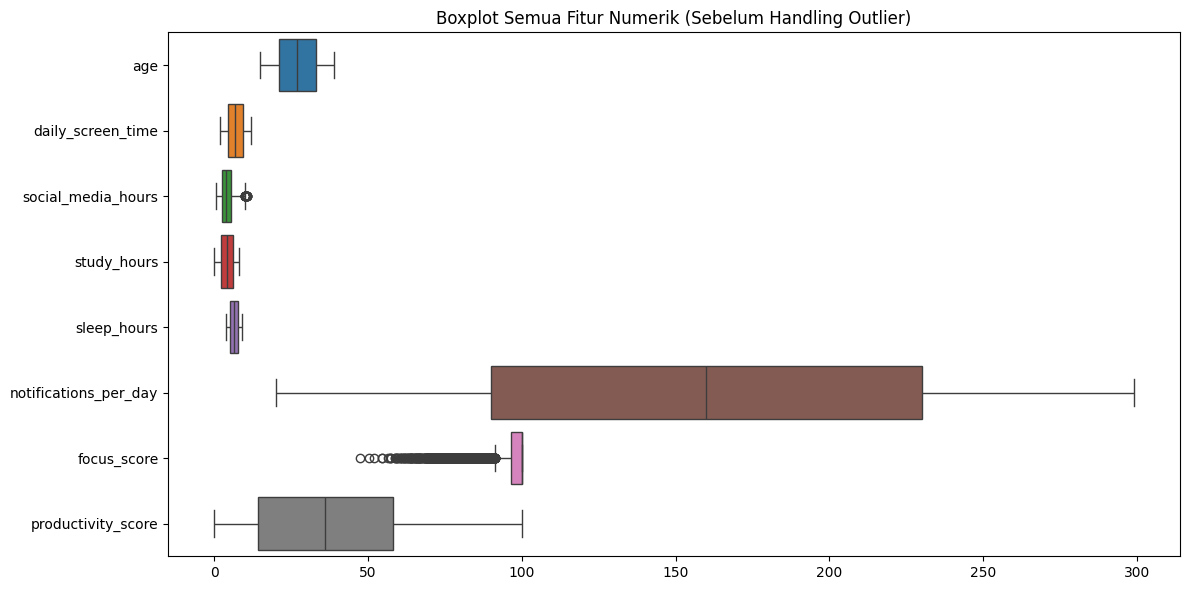

Jumlah outlier per kolom sebelum handling:
age: 0
daily_screen_time: 0
social_media_hours: 34
study_hours: 0
sleep_hours: 0
notifications_per_day: 0
focus_score: 966
productivity_score: 0


In [5]:
## Cek outlier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- Pilih kolom numerik ---
num_cols = df_clean.select_dtypes(include="number").columns

# --- 0️⃣ Convert kolom ke numeric (handle string / unknown) ---
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')  # invalid -> NaN

# Optional: isi NaN dengan median supaya bisa cek outlier
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# 1️⃣ Visualisasi boxplot sebelum handling
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[num_cols], orient='h')
plt.title("Boxplot Semua Fitur Numerik (Sebelum Handling Outlier)")
plt.tight_layout()
plt.show()

# 2️⃣ Hitung jumlah outlier per kolom pakai IQR
outlier_summary = {}
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_summary[col] = outliers

print("Jumlah outlier per kolom sebelum handling:")
for k, v in outlier_summary.items():
    print(f"{k}: {v}")


Jumlah outlier setelah handling:
age: 0
daily_screen_time: 0
social_media_hours: 0
study_hours: 0
sleep_hours: 0
notifications_per_day: 0
focus_score: 0
productivity_score: 0


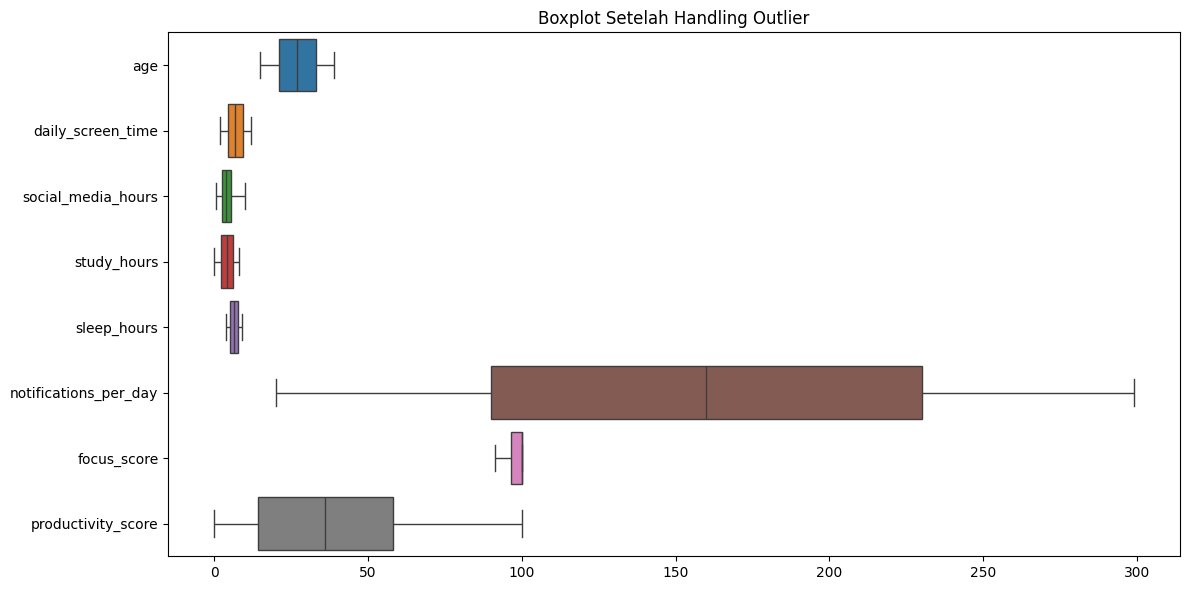

In [6]:
## handle outlier
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

strategy = 'cap'  # pilihan: 'remove', 'cap', 'robust'

df_handled = df_clean.copy()
if strategy == 'robust':
    # Robust scaling (tidak menghapus outlier, hanya menstabilkan distribusi)
    scaler = RobustScaler()
    df_handled[num_cols] = scaler.fit_transform(df_handled[num_cols])

else:
    if strategy == 'remove':
        # Buat mask global biar tidak kepotong berkali-kali
        mask = np.ones(len(df_handled), dtype=bool)

    for col in num_cols:
        Q1 = df_handled[col].quantile(0.25)
        Q3 = df_handled[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if strategy == 'remove':
            mask &= (df_handled[col] >= lower) & (df_handled[col] <= upper)

        elif strategy == 'cap':
            df_handled[col] = df_handled[col].clip(lower, upper)

    if strategy == 'remove':
        df_handled = df_handled[mask]
        
outlier_summary_after = {}
for col in num_cols:
    Q1 = df_handled[col].quantile(0.25)
    Q3 = df_handled[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df_handled[col] < lower) | (df_handled[col] > upper)).sum()
    outlier_summary_after[col] = outliers

print("\nJumlah outlier setelah handling:")
for k, v in outlier_summary_after.items():
    print(f"{k}: {v}")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_handled[num_cols], orient='h')
plt.title("Boxplot Setelah Handling Outlier")
plt.tight_layout()
plt.show()

In [7]:
## preprocessing + encoding + smote
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

target = "addiction_level"

# 1. SPLIT FEATURE & TARGET
X = df_handled.drop(columns=[target])
y = df_handled[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. AUTO DETECT CATEGORICA
categorical_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# 3. FIT ENCODER HANYA DI TRAIN
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

# 4. BALIK KE DATAFRAME & GABUNG
train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train_final = pd.concat([X_train.drop(columns=categorical_cols), train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(columns=categorical_cols), test_encoded_df], axis=1)

In [8]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRFClassifier
from sklearn.metrics import classification_report

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # fit di train
y_test_encoded = le.transform(y_test)        # transform aja di test

model = XGBRFClassifier(
    objective='multiclass',      # ganti ini juga! bukan binary kalau 3 class
    eval_metric='mlogloss',      # sesuaikan metric-nya
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train, y_train_encoded)

y_pred_encoded = model.predict(X_test_final)
y_pred = le.inverse_transform(y_pred_encoded)  # kembalikan ke label asli

print(classification_report(y_test, y_pred))

c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

        High       0.96      0.99      0.97       350
         Low       0.98      0.98      0.98       199
      Medium       0.99      0.97      0.98       651

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:41:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\fakhri\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:41:21] WARNING: C:\a

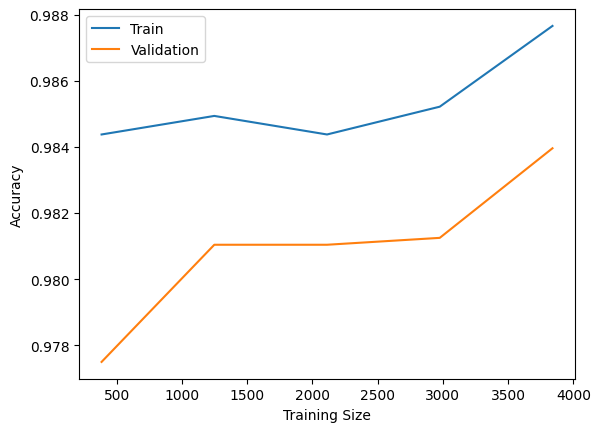

In [9]:
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Encode dulu y-nya
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Baru learning curve
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_final, y_train_encoded, cv=5, scoring='accuracy'  # <-- encoded!
)

# Plot
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_scores_mean, label='Train')
plt.plot(train_sizes, val_scores_mean, label='Validation')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()